In [14]:
import kagglehub

# E-ticaret Müşteri veriseti
path = kagglehub.dataset_download("carrie1/ecommerce-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-data' dataset.
Path to dataset files: /kaggle/input/ecommerce-data


In [15]:
import os

full_path = os.path.join(path, 'data.csv')

In [16]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#veri ön işleme
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# Algoritmalar ( Kümeleme)
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

#Boyut indirme
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#Değerlendirme Metrikleri

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score


from scipy.cluster.hierarchy import dendrogram, linkage


plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['font.size'] = 14
sns.set_style('whitegrid')
print('Herşey hazır')

Herşey hazır


In [17]:
raw_data = pd.read_csv(full_path, encoding="ISO-8859-1")

# Kümeleme için müşteri bazlı özet (Miktar, Fiyat vb.) tablosu
data = raw_data.groupby('CustomerID').agg({
    'Quantity': 'mean',
    'UnitPrice': 'mean'
}).reset_index()

df = data.copy()

print(f"Veri Seti Boyutu: {df.shape}")
print(f"Sütun sayısı: {len(df.columns)}")
print(f"Satır Sayısı: {len(df)}")

Veri Seti Boyutu: (4372, 3)
Sütun sayısı: 3
Satır Sayısı: 4372


In [18]:
#veri seti bilgisi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4372 non-null   float64
 1   Quantity    4372 non-null   float64
 2   UnitPrice   4372 non-null   float64
dtypes: float64(3)
memory usage: 102.6 KB


In [19]:
#Istatıksel Ozet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4372.0,15299.677722,1722.390705,12346.0,13812.750000,15300.500000,16778.250000,18287.00
Quantity,4372.0,22.389288,213.257466,-144.0,5.475745,9.494392,14.008333,12540.00
UnitPrice,4372.0,7.978608,144.963315,0.0,2.221431,2.944581,3.897209,8055.78


In [20]:
print('Eksik değerler')
print('--'*50)
print(df.isnull().sum()[df.isnull().sum()>0])
print(f'toplam eksik değer: {df.isnull().sum().sum()}')
print('--'*50)

Eksik değerler
----------------------------------------------------------------------------------------------------
Series([], dtype: int64)
toplam eksik değer: 0
----------------------------------------------------------------------------------------------------


In [21]:
df_columns =df.columns.str.strip()

In [23]:
# Müşteri ID sütununu index yapıyoruz
df.set_index('CustomerID', inplace=True)

imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)

print('Eksik değerler')
print('-'*50)
print(df_imputed.isnull().sum()[df_imputed.isnull().sum() > 0])
print(f'Toplam eksik değer: {df_imputed.isnull().sum().sum()}')
print('-'*50)

Eksik değerler
--------------------------------------------------
Series([], dtype: int64)
Toplam eksik değer: 0
--------------------------------------------------


In [24]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_imputed)
x_scaled = pd.DataFrame(x_scaled, columns=df_imputed.columns, index=df_imputed.index)

print('Ölçeklenmiş veri seti')
print('-'*50)
x_scaled.head(2)

Ölçeklenmiş veri seti
--------------------------------------------------


,Quantity,UnitPrice
CustomerID,,
12346.0,-0.104999,-0.047870
12347.0,-0.041662,-0.036804


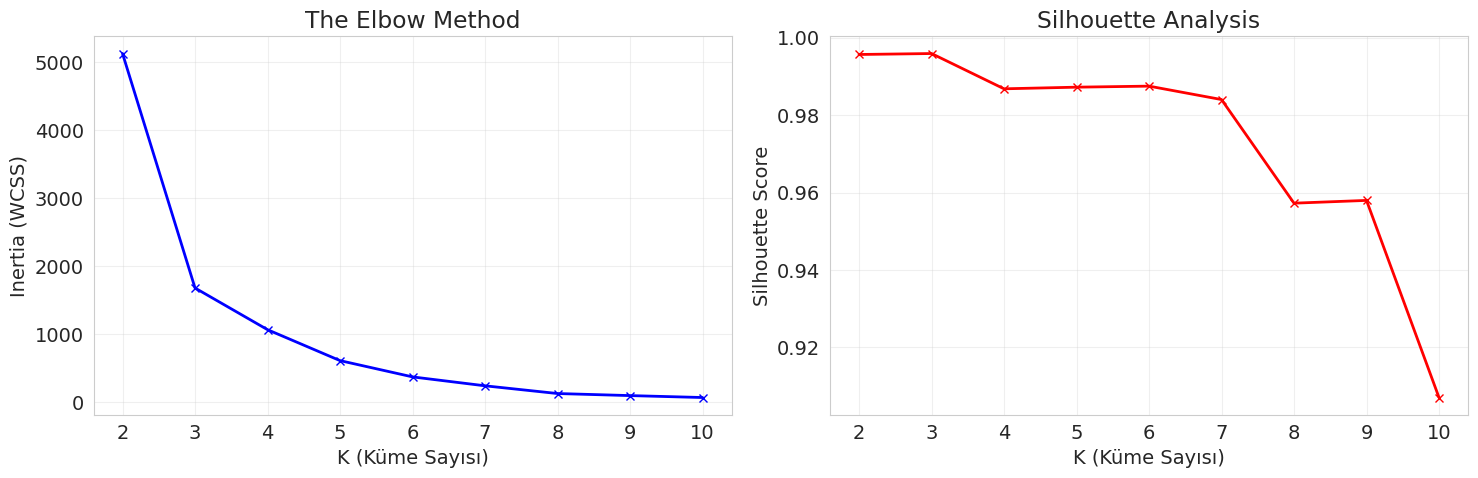

En iyi silhouette skoru: 0.9960
Optimum küme sayısı: 3


In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Listeleri tanımla
inertia = []
silhouette_scores = [] # Liste çoğul
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x_scaled, labels))

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sol Grafik: Elbow Method
axes[0].plot(K_range, inertia, 'bx-', linewidth=2)
axes[0].set_xlabel('K (Küme Sayısı)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('The Elbow Method')
axes[0].grid(True, alpha=0.3)

# Sağ Grafik: Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'rx-', linewidth=2)
axes[1].set_xlabel('K (Küme Sayısı)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# En iyi K değerini hesapla
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhouette skoru: {max(silhouette_scores):.4f}')
print(f'Optimum küme sayısı: {optimal_k}')

In [26]:
# Optimum K ile K-Means modelini eğit (Grafikten gelen optimal_k değerini kullanır)
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(x_scaled)

print('K-means Kümeleme Sonuçları:')
print(f'Küme sayısı: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(x_scaled, kmeans_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(x_scaled, kmeans_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(x_scaled, kmeans_labels):.4f}')
print('\nKüme dağılımı:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-means Kümeleme Sonuçları:
Küme sayısı: 3
Silhouette Skoru: 0.9960
Davies Bouldin Skoru: 0.2650
Calinski Harabasz Skoru: 9193.3927

Küme dağılımı:
0    4369
1       2
2       1
Name: count, dtype: int64


In [27]:
# K-Means kümelerinin özetleri
df_imputed['KMeans_Cluster'] = kmeans_labels
cluster_summary = df_imputed.groupby('KMeans_Cluster').mean().round(2)

print('K-Means Küme Profilleri:')
cluster_summary

K-Means Küme Profilleri:


,Quantity,UnitPrice
KMeans_Cluster,,
0,19.53,5.16
1,5.50,6171.70
2,12540.00,0.00


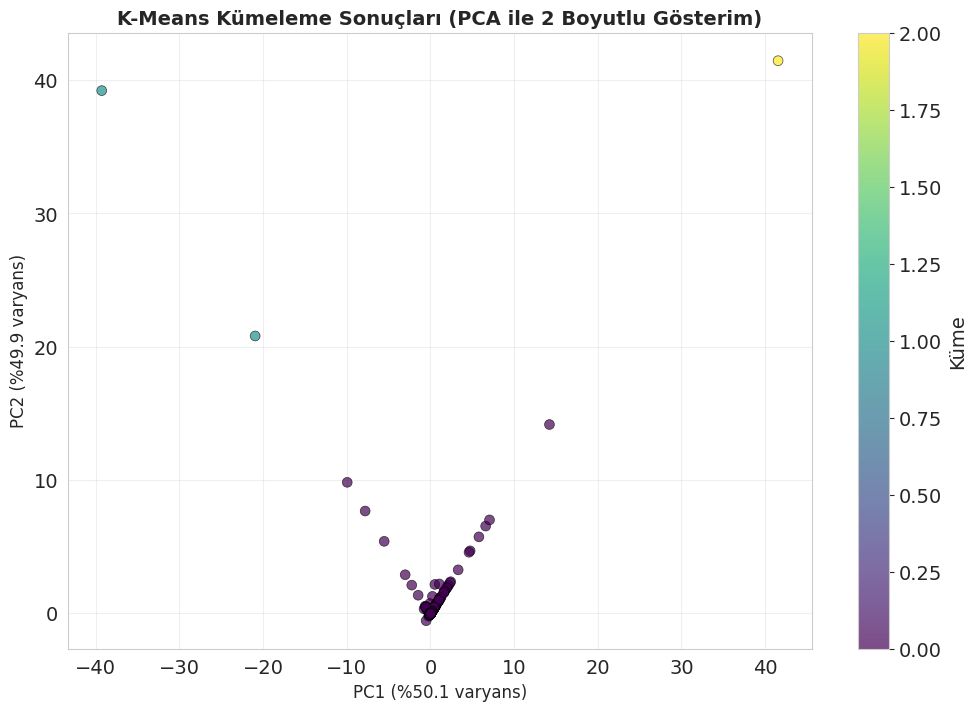

In [28]:
# PCA ile K-Means görselleştirmesi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7, s=50, edgecolors='k', linewidth=0.5)

plt.colorbar(scatter, label='Küme')
plt.title('K-Means Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()